# 01 - Exploratory Data Analysis

## Objective

This notebook explores the raw MotoStock dataset before any preparation or modeling. It checks the dataset structure, data quality and the main demand patterns by product, category and date.

The goal is to understand which information can help a daily product demand forecast without making unsupported business claims.

**Input:** `data/raw/motoretail.csv`  
**Output:** analysis only; the raw data is not changed  
**Next notebook:** `02_data_preparation.ipynb`

## Imports and Settings

In [1]:
import os
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

## Load Dataset

In [2]:
DATA_PATH = ROOT / "data" / "raw" / "motoretail.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Date values:", df["sale_date"].min(), "to", df["sale_date"].max())
df.head()

Shape: (6875, 27)
Date values: 2025-01-01 to 2026-05-29


,sale_date,sale_time,day_of_week,month,customer_type,customer_city,customer_state,customer_neighborhood,customer_address,customer_zipcode,product_name,product_category,quantity_sold,unit_cost_brl,unit_price_brl,discount_pct,total_revenue_brl,estimated_profit_brl,payment_method,sales_channel,weather_condition,delivery_app_peak,is_weekend,is_holiday_campaign,current_stock_snapshot,supplier_lead_time_days,returned
0,2025-01-01,16:00,Quarta-feira,Janeiro,Novo,Caldas Novas,GO,Itanhangá II,"Rua São Paulo, 530",75680-195,Capacete Pro Tork,Capacete,1,180,333.75,0,333.75,153.75,Pix,Loja Física,Ensolarado,True,False,False,102,10,False
1,2025-01-01,14:30,Quarta-feira,Janeiro,Recorrente,Caldas Novas,GO,Jardim Belvedere,"Rua do Balneário, 3537",75685-204,Luva Motoboy,Proteção,2,25,77.39,0,154.78,104.78,Pix,Instagram,Ensolarado,False,False,False,23,9,False
2,2025-01-01,13:15,Quarta-feira,Janeiro,Recorrente,Caldas Novas,GO,Portal das Águas,"Av. Orcalino Santos, 760",75683-891,Retrovisor Esportivo,Peça,1,35,119.85,0,119.85,84.85,Pix,Loja Física,Ensolarado,True,False,False,54,9,False
3,2025-01-01,18:00,Quarta-feira,Janeiro,Novo,Caldas Novas,GO,Itanhangá II,"Rua do Balneário, 8761",75683-267,Suporte Celular Moto,Suporte,1,18,60.55,0,60.55,42.55,Pix,Instagram,Ensolarado,False,False,False,47,7,False
4,2025-01-01,11:30,Quarta-feira,Janeiro,Novo,Caldas Novas,GO,Nova Vila,"Rua São Paulo, 6492",75687-246,Capacete Pro Tork,Capacete,1,180,324.42,0,324.42,144.42,Pix,WhatsApp,Ensolarado,True,False,False,93,8,False


## Dataset Structure

Each raw row is a sales transaction. The table below helps confirm column types and whether each column is complete.

In [3]:
structure_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_rows": df.notna().sum(),
    "unique_values": df.nunique(dropna=True),
}).reset_index(names="column")

structure_df

,column,dtype,non_null_rows,unique_values
0,sale_date,str,6875,514
1,sale_time,str,6875,52
2,day_of_week,str,6875,7
3,month,str,6875,12
4,customer_type,str,6875,3
5,customer_city,str,6875,1
6,customer_state,str,6875,1
7,customer_neighborhood,str,6875,6
8,customer_address,str,6875,6329
9,customer_zipcode,str,6875,4764


## Data Quality Checks

In [4]:
df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")

missing_df = (
    df.isna().sum().to_frame("missing_rows")
    .assign(missing_pct=lambda x: x["missing_rows"] / len(df) * 100)
    .query("missing_rows > 0")
)

print("Missing or invalid dates:", df["sale_date"].isna().sum())
print("Fully duplicated rows:", df.duplicated().sum())
print("Products:", df["product_name"].nunique())
print("Categories:", df["product_category"].nunique())
display(missing_df if not missing_df.empty else pd.DataFrame({"result": ["No missing values"]}))

Missing or invalid dates: 0
Fully duplicated rows: 0
Products: 12
Categories: 8


,result
0,No missing values


In [5]:
non_negative_columns = [
    "quantity_sold", "unit_cost_brl", "unit_price_brl",
    "total_revenue_brl", "estimated_profit_brl",
    "current_stock_snapshot", "supplier_lead_time_days",
]

quality_checks_df = pd.DataFrame({
    "check": [
        "Negative values in non-negative columns",
        "Discount below 0%",
        "Discount above 100%",
        "Product/category inconsistent mappings",
        "Dates with more than one weather label",
    ],
    "rows_or_groups": [
        int((df[non_negative_columns] < 0).sum().sum()),
        int((df["discount_pct"] < 0).sum()),
        int((df["discount_pct"] > 100).sum()),
        int((df.groupby("product_name")["product_category"].nunique() > 1).sum()),
        int((df.groupby("sale_date")["weather_condition"].nunique() > 1).sum()),
    ],
})

quality_checks_df

,check,rows_or_groups
0,Negative values in non-negative columns,0
1,Discount below 0%,0
2,Discount above 100%,0
3,Product/category inconsistent mappings,0
4,Dates with more than one weather label,513


More than one weather label can appear on the same date because the raw data contains transactions from different times. The preparation notebook will use the most frequent weather label for each date so weather is a consistent date-level category.

## Demand Distribution

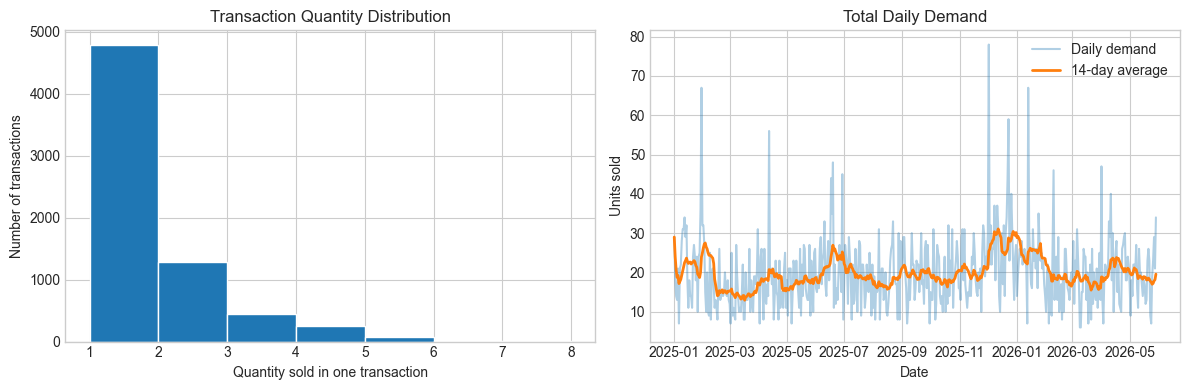

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["quantity_sold"], bins=range(1, int(df["quantity_sold"].max()) + 2), edgecolor="white")
axes[0].set_title("Transaction Quantity Distribution")
axes[0].set_xlabel("Quantity sold in one transaction")
axes[0].set_ylabel("Number of transactions")

daily_demand = df.groupby("sale_date", as_index=False)["quantity_sold"].sum()
daily_demand["rolling_14d"] = daily_demand["quantity_sold"].rolling(14, min_periods=1).mean()
axes[1].plot(daily_demand["sale_date"], daily_demand["quantity_sold"], alpha=0.35, label="Daily demand")
axes[1].plot(daily_demand["sale_date"], daily_demand["rolling_14d"], linewidth=2, label="14-day average")
axes[1].set_title("Total Daily Demand")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Units sold")
axes[1].legend()

plt.tight_layout()
plt.show()

## Product and Category Performance

In [7]:
category_summary = (
    df.groupby("product_category", as_index=False)
    .agg(
        units_sold=("quantity_sold", "sum"),
        revenue_brl=("total_revenue_brl", "sum"),
        estimated_profit_brl=("estimated_profit_brl", "sum"),
        products=("product_name", "nunique"),
    )
    .sort_values("units_sold", ascending=False)
)
category_summary.round(2)

,product_category,units_sold,revenue_brl,estimated_profit_brl,products
6,Proteção,3212,257445.15,172759.15,3
1,Bag Entrega,2839,580161.89,270456.89,2
7,Suporte,1732,102122.75,70946.75,1
3,Capacete,1099,412445.33,187225.33,2
2,Bagagem,589,152366.89,81686.89,1
0,Acessório,387,18981.91,13176.91,1
5,Peça,322,38446.76,27176.76,1
4,Eletrônico,52,20716.26,12916.26,1


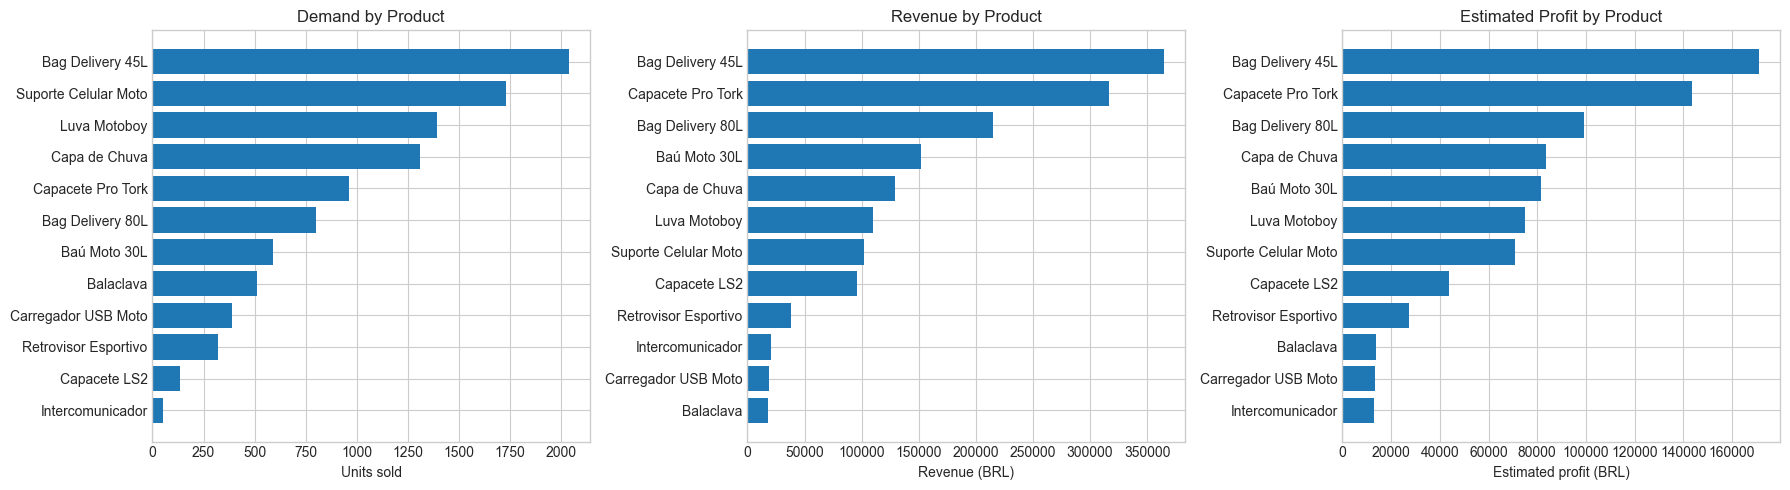

,product_name,category,units_sold,revenue_brl,estimated_profit_brl
0,Bag Delivery 45L,Bag Entrega,2039,364877.87,171172.87
11,Suporte Celular Moto,Suporte,1732,102122.75,70946.75
9,Luva Motoboy,Proteção,1391,109944.88,75169.88
4,Capa de Chuva,Proteção,1309,129587.86,83772.86
6,Capacete Pro Tork,Capacete,962,316685.59,143525.59
1,Bag Delivery 80L,Bag Entrega,800,215284.02,99284.02
3,Baú Moto 30L,Bagagem,589,152366.89,81686.89
2,Balaclava,Proteção,512,17912.41,13816.41
7,Carregador USB Moto,Acessório,387,18981.91,13176.91
10,Retrovisor Esportivo,Peça,322,38446.76,27176.76


In [8]:
product_summary = (
    df.groupby("product_name", as_index=False)
    .agg(
        category=("product_category", "first"),
        units_sold=("quantity_sold", "sum"),
        revenue_brl=("total_revenue_brl", "sum"),
        estimated_profit_brl=("estimated_profit_brl", "sum"),
    )
    .sort_values("units_sold", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column, title, label in [
    (axes[0], "units_sold", "Demand by Product", "Units sold"),
    (axes[1], "revenue_brl", "Revenue by Product", "Revenue (BRL)"),
    (axes[2], "estimated_profit_brl", "Estimated Profit by Product", "Estimated profit (BRL)"),
]:
    plot_data = product_summary.sort_values(column)
    ax.barh(plot_data["product_name"], plot_data[column])
    ax.set_title(title)
    ax.set_xlabel(label)

plt.tight_layout()
plt.show()

product_summary.round(2)

## Calendar and Weather Patterns

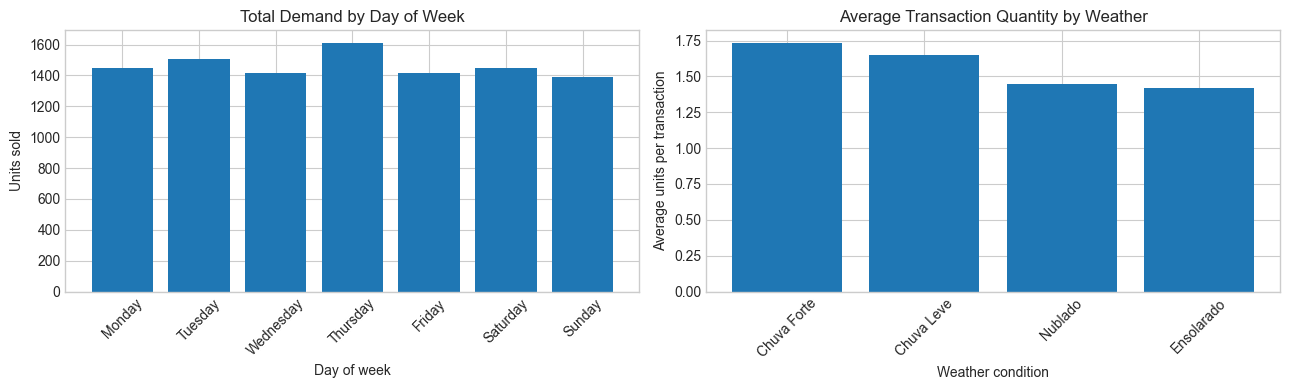

,weather_condition,total_units,transactions,average_units
0,Chuva Forte,777,448,1.73
1,Chuva Leve,2035,1235,1.65
3,Nublado,2545,1762,1.44
2,Ensolarado,4875,3430,1.42


In [9]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
calendar_summary = (
    df.assign(day_of_week=df["sale_date"].dt.day_name())
    .groupby("day_of_week", as_index=False)["quantity_sold"].sum()
    .assign(day_of_week=lambda x: pd.Categorical(x["day_of_week"], categories=day_order, ordered=True))
    .sort_values("day_of_week")
)

weather_summary = (
    df.groupby("weather_condition", as_index=False)
    .agg(total_units=("quantity_sold", "sum"), transactions=("quantity_sold", "size"), average_units=("quantity_sold", "mean"))
    .sort_values("average_units", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(calendar_summary["day_of_week"].astype(str), calendar_summary["quantity_sold"])
axes[0].set_title("Total Demand by Day of Week")
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Units sold")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(weather_summary["weather_condition"], weather_summary["average_units"])
axes[1].set_title("Average Transaction Quantity by Weather")
axes[1].set_xlabel("Weather condition")
axes[1].set_ylabel("Average units per transaction")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
weather_summary.round(2)

## Latest Stock Snapshot

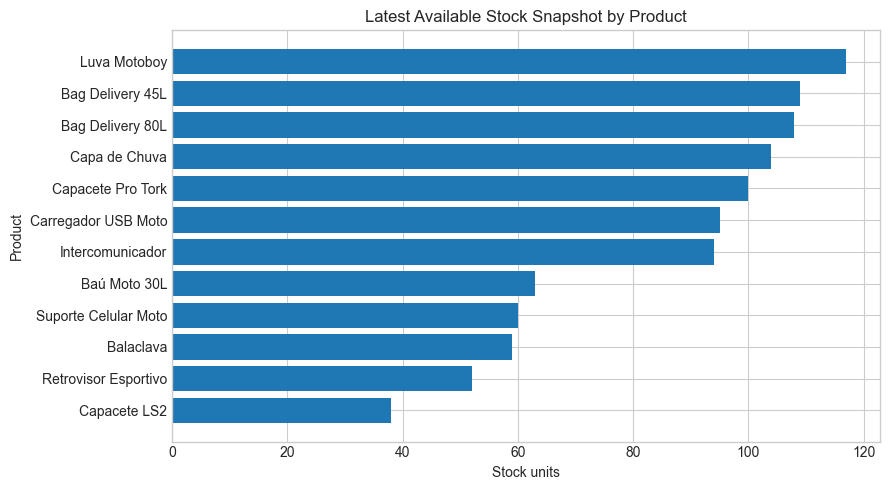

,product_name,sale_date,current_stock_snapshot
6826,Capacete LS2,2026-05-27,38
6835,Retrovisor Esportivo,2026-05-27,52
6821,Balaclava,2026-05-26,59
6859,Suporte Celular Moto,2026-05-29,60
6867,Baú Moto 30L,2026-05-29,63
6708,Intercomunicador,2026-05-17,94
6874,Carregador USB Moto,2026-05-29,95
6860,Capacete Pro Tork,2026-05-29,100
6862,Capa de Chuva,2026-05-29,104
6861,Bag Delivery 80L,2026-05-29,108


In [10]:
latest_stock = (
    df.sort_values(["product_name", "sale_date", "sale_time"])
    .groupby("product_name", as_index=False)
    .tail(1)[["product_name", "sale_date", "current_stock_snapshot"]]
    .sort_values("current_stock_snapshot")
)

plt.figure(figsize=(9, 5))
plt.barh(latest_stock["product_name"], latest_stock["current_stock_snapshot"])
plt.title("Latest Available Stock Snapshot by Product")
plt.xlabel("Stock units")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

latest_stock

## Findings and Limitations

The tables above show that demand, revenue and estimated profit are not distributed equally across products. Product-level forecasting is therefore more useful than one total forecast. The daily chart also shows short-term variation, which supports the use of lag and rolling features later in the project.

Weather comparisons are descriptive only. A weather group with more transactions can have a larger total even when weather is not the cause. Revenue and estimated profit also depend on price and product mix.

The stock column is a transaction-time snapshot, not a stock movement history. It must not be summed. The latest valid snapshot will be used later as the best available estimate of current stock.

## Summary and Next Step

The raw data has transaction-level rows and needs to be converted to one row per product per day. The next notebook will aggregate transactions, add zero-sales product-days and document how snapshot and category columns are handled.